# Tarefa de Machine Learning — Regressão e Classificação

Isaac Vianna

Notebook dividido em três partes: (1) regressão do `score` dos alunos (Student Performance), (2) classificação do diagnóstico (Breast Cancer Wisconsin) e (3) geração das submissões para o Kaggle.

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, train_test_split,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier,
)
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


---
# Parte 1 — Regressão (Student Performance)

`score` é a média de `G1`, `G2` e `G3` (0 a 20). Antes de qualquer código, o dicionário de dados (`student.txt`) foi lido: colunas como `Medu`, `Fedu`, `traveltime`, `studytime`, `failures`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, `health` são escalas ordinais (1-5) já numéricas, e `Mjob`, `Fjob`, `reason`, `guardian`, `school`, `sex`, `address`, `famsize`, `Pstatus`, `schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic` são categóricas (nominais ou binárias) de texto.

In [35]:
train_reg = pd.read_csv("regressao/train.csv")
test_reg = pd.read_csv("regressao/test.csv")
train_reg.shape, test_reg.shape

((395, 31), (40, 30))

## 1.1 Análise exploratória (EDA)

In [36]:
print("shape:", train_reg.shape)
print()
print(train_reg.dtypes)
print()
print("nulos por coluna:")
print(train_reg.isna().sum().sum(), "nulos no total")
print("linhas duplicadas:", train_reg.duplicated().sum())

shape: (395, 31)

school         object
sex            object
age             int64
address        object
famsize        object
Pstatus        object
Medu            int64
Fedu            int64
Mjob           object
Fjob           object
reason         object
guardian       object
traveltime      int64
studytime       int64
failures        int64
schoolsup      object
famsup         object
paid           object
activities     object
nursery        object
higher         object
internet       object
romantic       object
famrel          int64
freetime        int64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
score         float64
dtype: object

nulos por coluna:
0 nulos no total
linhas duplicadas: 0


In [37]:
train_reg["score"].describe()

count    395.000000
mean      10.679139
std        3.696912
min        1.330000
25%        8.330000
50%       10.670000
75%       13.330000
max       19.330000
Name: score, dtype: float64

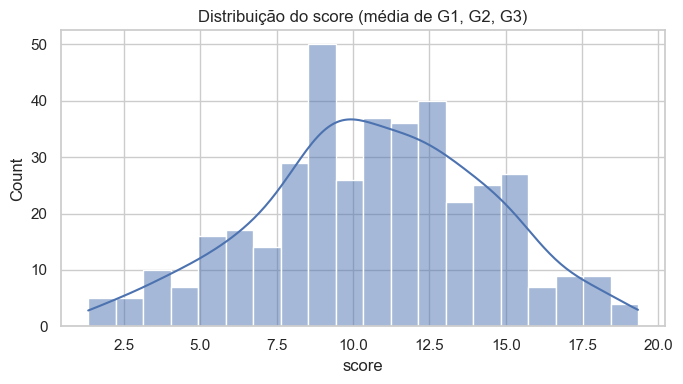

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train_reg["score"], bins=20, kde=True, ax=ax)
ax.set_title("Distribuição do score (média de G1, G2, G3)")
ax.set_xlabel("score")
plt.tight_layout()
plt.show()

O `score` tem média em torno de 10.7 e varia de 1.33 a 19.33 nos dados de treino, com um formato próximo do normal, levemente concentrado entre 8 e 14. Há uma cauda de notas baixas (alunos com score entre 1 e 3), possivelmente reprovados ou desistentes.

In [39]:
ordinal_cols = ["Medu", "Fedu", "traveltime", "studytime", "failures",
                "famrel", "freetime", "goout", "Dalc", "Walc", "health"]
numeric_cols = ordinal_cols + ["age", "absences"]
categorical_cols = [c for c in train_reg.columns if c not in numeric_cols + ["score"]]
print("numéricas/ordinais:", numeric_cols)
print("categóricas:", categorical_cols)

numéricas/ordinais: ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'age', 'absences']
categóricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


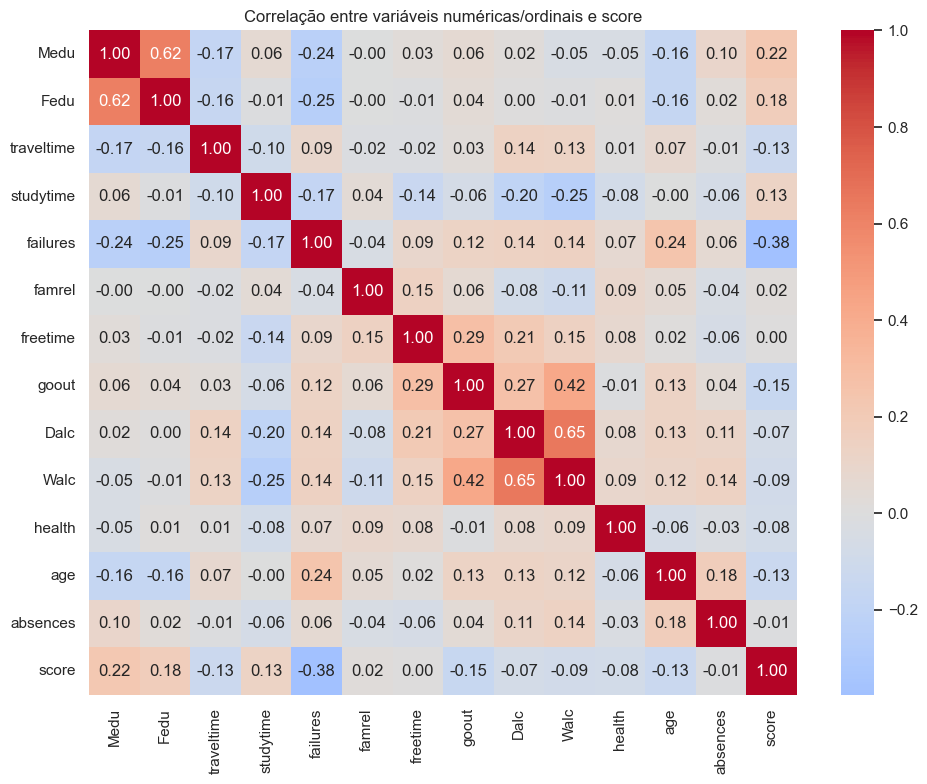

In [40]:
corr = train_reg[numeric_cols + ["score"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre variáveis numéricas/ordinais e score")
plt.tight_layout()
plt.show()

`failures` (número de reprovações anteriores) é a variável com correlação negativa mais forte com `score` — quem já reprovou tende a tirar notas mais baixas. `Medu`/`Fedu` (escolaridade dos pais) têm correlação positiva fraca a moderada. `absences` tem correlação quase nula com `score`, o que é um pouco contraintuitivo mas consistente com a literatura desse dataset (faltas concentradas em poucos alunos).

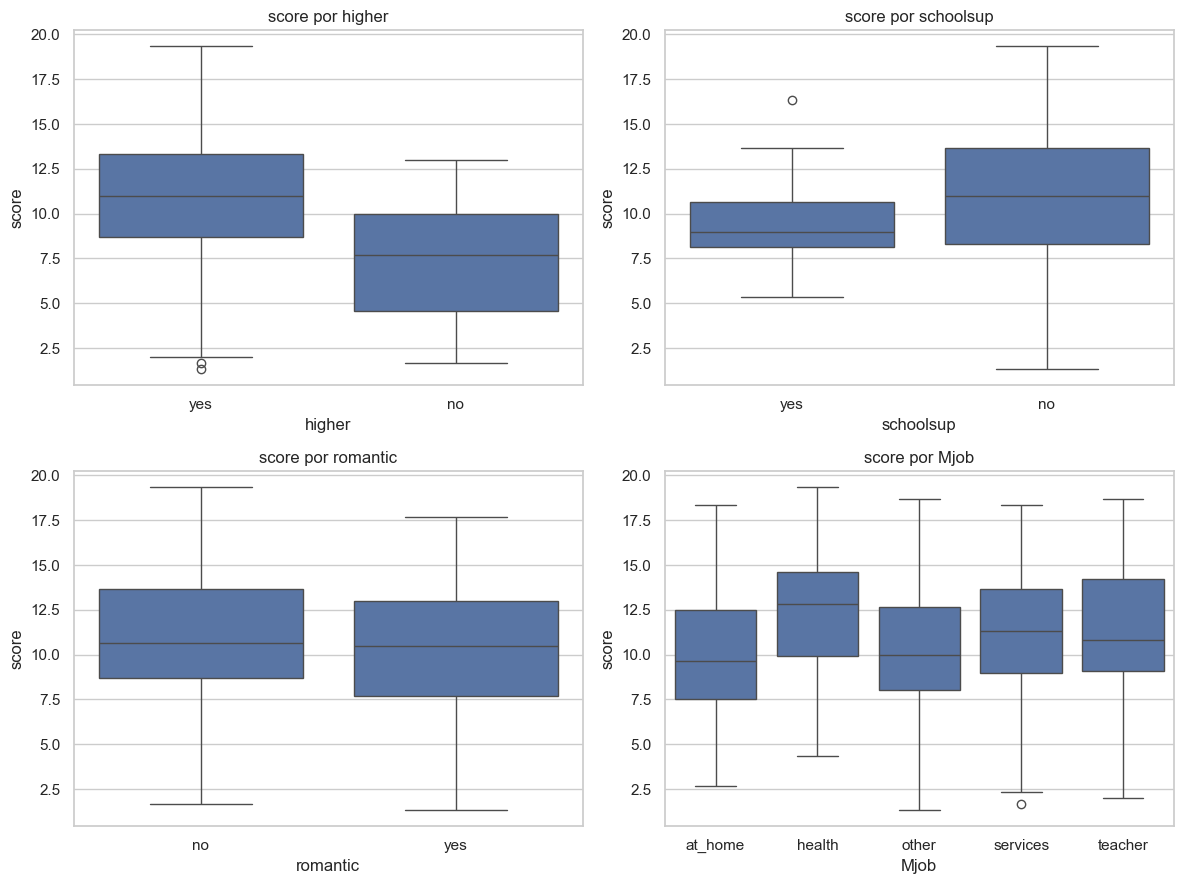

In [41]:
cat_to_plot = ["higher", "schoolsup", "romantic", "Mjob"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), cat_to_plot):
    sns.boxplot(data=train_reg, x=col, y="score", ax=ax)
    ax.set_title(f"score por {col}")
plt.tight_layout()
plt.show()

Alunos que pretendem cursar ensino superior (`higher = yes`) têm score visivelmente maior e menos dispersão do que os que não pretendem. Quem recebe apoio educacional extra (`schoolsup = yes`) tende a ter score um pouco menor — provavelmente porque o apoio é dado justamente a quem já tem dificuldade (causalidade reversa, não o apoio causando nota pior). `romantic` e `Mjob` mostram diferenças mais discretas entre grupos.

## 1.2 Limpeza e pré-processamento

In [42]:
leak_cols = [c for c in ["G1", "G2", "G3"] if c in train_reg.columns]
print("colunas de vazamento encontradas:", leak_cols)
assert len(leak_cols) == 0, "G1/G2/G3 não podem estar entre as features"
assert train_reg.shape[1] == 31, "esperado 30 features + score"
print("OK: 30 features + score, sem G1/G2/G3.")

colunas de vazamento encontradas: []
OK: 30 features + score, sem G1/G2/G3.


As colunas ordinais (`Medu`, `Fedu`, `traveltime`, `studytime`, `failures`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, `health`) já são numéricas e são mantidas como número, sem one-hot. As colunas nominais/binárias de texto vão para `OneHotEncoder`. O pré-processamento (one-hot + padronização) é encapsulado em um `ColumnTransformer` dentro de um `Pipeline`, então `fit` só acontece no treino de cada fold — sem vazamento entre folds nem em relação ao `test.csv`.

In [43]:
preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ]
)

X_reg = train_reg.drop(columns=["score"])
y_reg = train_reg["score"]
X_reg.shape, y_reg.shape

((395, 30), (395,))

## 1.3 Modelos

In [44]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "SVR": SVR(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_results = []
for name, model in reg_models.items():
    pipe = Pipeline([("preprocess", preprocess_reg), ("model", model)])
    scores = cross_val_score(pipe, X_reg, y_reg, cv=kf, scoring="neg_root_mean_squared_error")
    rmse_scores = -scores
    reg_results.append({"modelo": name, "rmse_medio": rmse_scores.mean(), "rmse_std": rmse_scores.std()})

reg_results_df = pd.DataFrame(reg_results).sort_values("rmse_medio").reset_index(drop=True)
reg_results_df

,modelo,rmse_medio,rmse_std
0,RandomForestRegressor,3.228587,0.163383
1,GradientBoostingRegressor,3.284579,0.055156
2,SVR,3.354405,0.252565
3,Ridge,3.449405,0.104649
4,LinearRegression,3.459303,0.111004
5,Lasso,3.563362,0.264725
6,KNeighborsRegressor,3.591126,0.261052
7,DecisionTreeRegressor,4.581951,0.460960


In [45]:
champion_reg_name = reg_results_df.iloc[0]["modelo"]
print("Modelo campeão (regressão):", champion_reg_name)

Modelo campeão (regressão): RandomForestRegressor


Ajuste de hiperparâmetros com `GridSearchCV` apenas no modelo campeão, com um grid pequeno em torno dos hiperparâmetros mais relevantes daquela família.

In [46]:
reg_param_grids = {
    "LinearRegression": {"model__fit_intercept": [True, False]},
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0, 30.0]},
    "Lasso": {"model__alpha": [0.001, 0.01, 0.1, 1.0]},
    "KNeighborsRegressor": {"model__n_neighbors": [3, 5, 7, 9, 11], "model__weights": ["uniform", "distance"]},
    "SVR": {"model__C": [0.1, 1, 10], "model__kernel": ["linear", "rbf"], "model__gamma": ["scale"]},
    "DecisionTreeRegressor": {"model__max_depth": [3, 5, 7, None], "model__min_samples_leaf": [1, 2, 4]},
    "RandomForestRegressor": {"model__n_estimators": [100, 200, 300], "model__max_depth": [None, 5, 10]},
    "GradientBoostingRegressor": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
}

champion_pipe_reg = Pipeline([("preprocess", preprocess_reg), ("model", reg_models[champion_reg_name])])
grid_reg = GridSearchCV(
    champion_pipe_reg,
    reg_param_grids[champion_reg_name],
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid_reg.fit(X_reg, y_reg)

print("Melhores hiperparâmetros:", grid_reg.best_params_)
print(f"RMSE (CV) antes do tuning: {reg_results_df.iloc[0]['rmse_medio']:.4f}")
print(f"RMSE (CV) depois do tuning: {-grid_reg.best_score_:.4f}")

Melhores hiperparâmetros: {'model__max_depth': 10, 'model__n_estimators': 300}
RMSE (CV) antes do tuning: 3.2286
RMSE (CV) depois do tuning: 3.2046


## 1.4 Métrica

In [47]:
best_reg_pipe = grid_reg.best_estimator_

mae_scores = -cross_val_score(best_reg_pipe, X_reg, y_reg, cv=kf, scoring="neg_mean_absolute_error")
r2_scores = cross_val_score(best_reg_pipe, X_reg, y_reg, cv=kf, scoring="r2")
rmse_final = -cross_val_score(best_reg_pipe, X_reg, y_reg, cv=kf, scoring="neg_root_mean_squared_error")

print(f"RMSE: {rmse_final.mean():.4f} +- {rmse_final.std():.4f}")
print(f"MAE:  {mae_scores.mean():.4f} +- {mae_scores.std():.4f}")
print(f"R2:   {r2_scores.mean():.4f} +- {r2_scores.std():.4f}")

RMSE: 3.2046 +- 0.1763
MAE:  2.5278 +- 0.1869
R2:   0.2370 +- 0.0338


**Justificativa:** o modelo final é o de menor RMSE médio em validação cruzada (5 folds), já com hiperparâmetros ajustados via `GridSearchCV`. RMSE é a métrica-alvo do enunciado e do leaderboard do Kaggle; MAE e R² são reportados como complemento — MAE dá o erro médio absoluto em pontos de nota (mais fácil de interpretar) e R² mostra a fração da variância do `score` explicada pelo modelo.

---
# Parte 2 — Classificação (Breast Cancer Wisconsin)

Alvo `diagnosis`: `M` = maligno, `B` = benigno. 30 features numéricas (10 medidas × `_mean`/`_se`/`_worst`).

In [48]:
train_clf = pd.read_csv("classiicacao/train2.csv")
test_clf = pd.read_csv("classiicacao/test2.csv")
train_clf.shape, test_clf.shape

((569, 31), (40, 30))

## 2.1 Análise exploratória

In [49]:
print("shape:", train_clf.shape)
print()
print(train_clf.dtypes.value_counts())
print()
print("nulos:", train_clf.isna().sum().sum())

id_like_cols = [c for c in train_clf.columns if c == "id" or c.startswith("Unnamed")]
print("colunas tipo id/Unnamed encontradas:", id_like_cols)
if id_like_cols:
    train_clf = train_clf.drop(columns=id_like_cols)
    print("dropadas:", id_like_cols)

shape: (569, 31)

float64    30
object      1
Name: count, dtype: int64

nulos: 0
colunas tipo id/Unnamed encontradas: []


In [50]:
counts = train_clf["diagnosis"].value_counts()
props = train_clf["diagnosis"].value_counts(normalize=True)
print(counts)
print(props)
baseline_acc = props.max()
print(f"\nPiso de acurácia (sempre prever a classe majoritária): {baseline_acc:.2%}")

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

Piso de acurácia (sempre prever a classe majoritária): 62.74%


357 amostras benignas (B) e 212 malignas (M), ou seja, ~62.7% / 37.3% — um desbalanceamento leve. **62.7% é o piso de acurácia**: um modelo que responde sempre "benigno" já acerta isso, sem nenhum valor clínico. Qualquer modelo treinado precisa superar esse número com folga, e a acurácia sozinha não deve ser o único critério de avaliação.

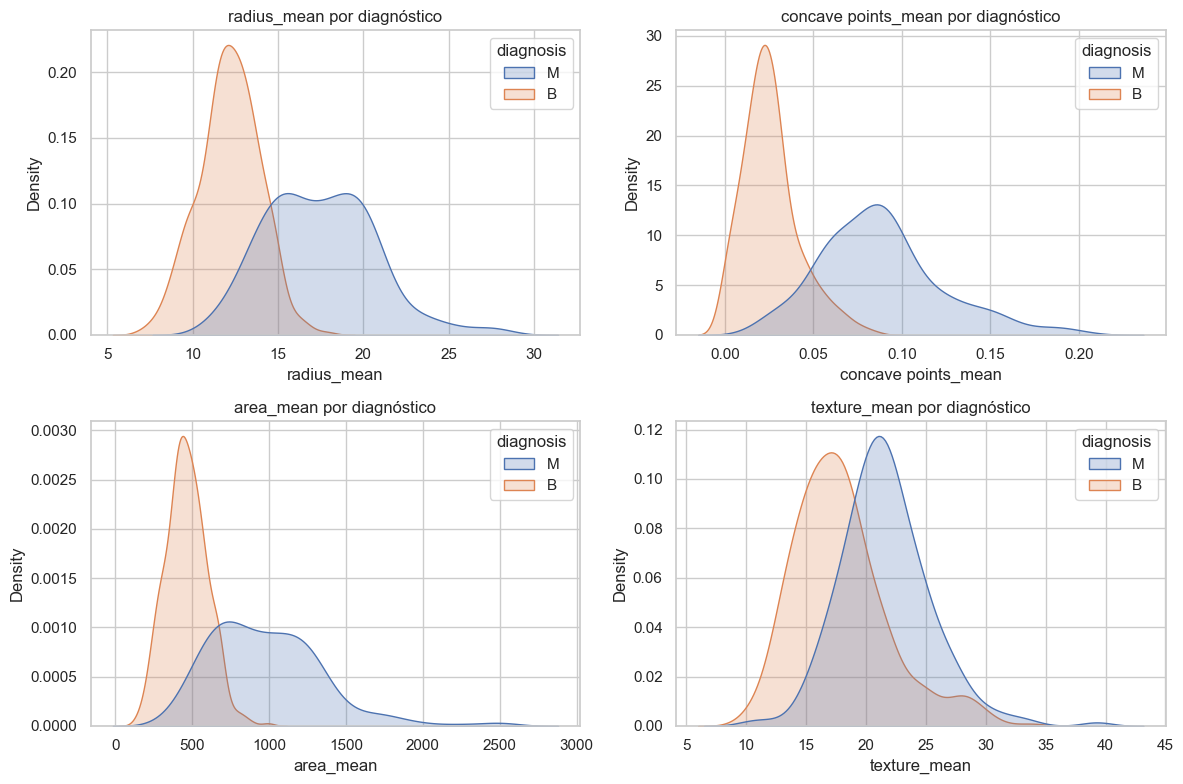

In [51]:
feat_to_plot = ["radius_mean", "concave points_mean", "area_mean", "texture_mean"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), feat_to_plot):
    sns.kdeplot(data=train_clf, x=col, hue="diagnosis", fill=True, common_norm=False, ax=ax)
    ax.set_title(f"{col} por diagnóstico")
plt.tight_layout()
plt.show()

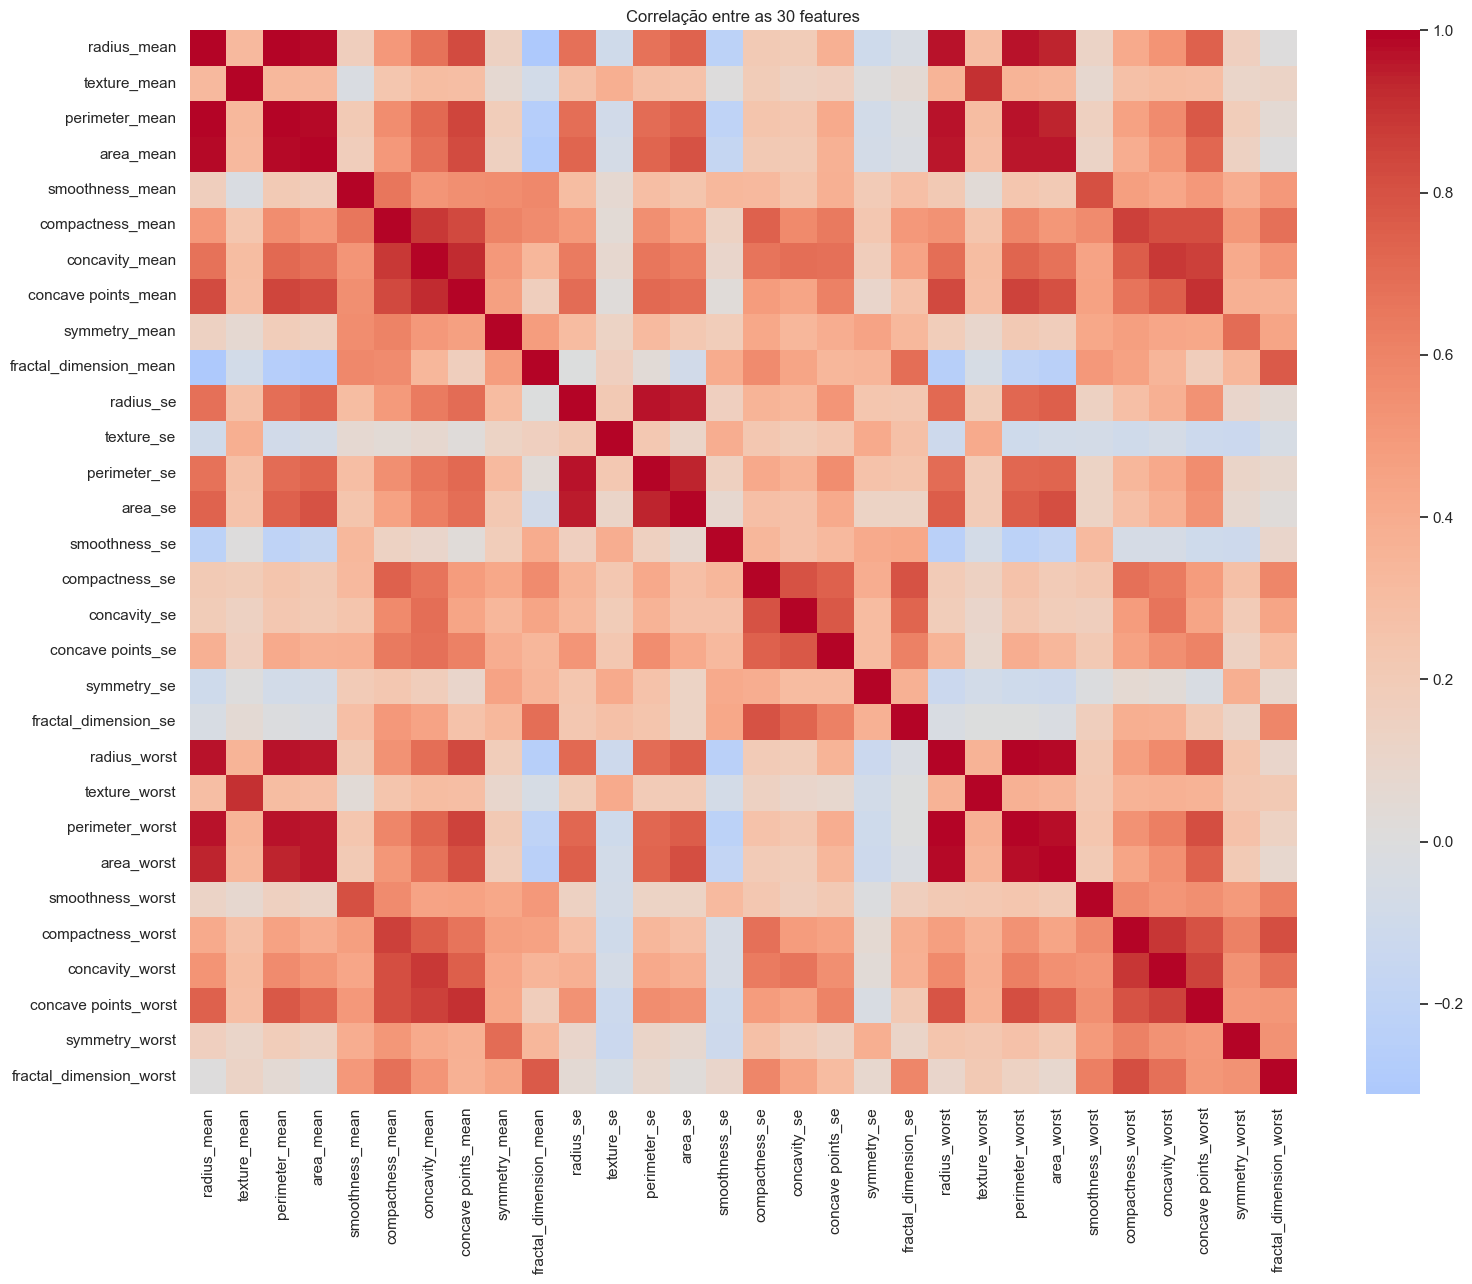

In [52]:
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(train_clf.drop(columns=["diagnosis"]).corr(), cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre as 30 features")
plt.tight_layout()
plt.show()

As distribuições de `radius_mean`, `concave points_mean` e `area_mean` separam bem as duas classes — tumores malignos tendem a ter núcleos maiores e bordas mais irregulares (mais "concave points"). No heatmap, as versões `_mean` e `_worst` da mesma medida (ex.: `radius_mean` e `radius_worst`) são fortemente correlacionadas entre si, como esperado, já que `_worst` é a média dos três maiores valores da mesma medida — isso é redundância esperada e não é tratado aqui pois os modelos usados (especialmente os baseados em árvore e regularização) toleram bem features correlacionadas.

## 2.2 Pré-processamento

In [53]:
if train_clf["diagnosis"].dtype == object:
    train_clf["diagnosis"] = train_clf["diagnosis"].map({"M": 1, "B": 0})
print("Codificação: M -> 1 (maligno), B -> 0 (benigno)")

Codificação: M -> 1 (maligno), B -> 0 (benigno)


In [54]:
X_clf = train_clf.drop(columns=["diagnosis"])
y_clf = train_clf["diagnosis"]

preprocess_clf = ColumnTransformer(
    transformers=[("num", StandardScaler(), X_clf.columns.tolist())]
)
X_clf.shape, y_clf.shape

((569, 30), (569,))

## 2.3 Modelos

In [55]:
clf_models = {
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE, max_iter=5000),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "GaussianNB": GaussianNB(),
    "SVC (linear)": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
    "SVC (rbf)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

clf_results = []
for name, model in clf_models.items():
    pipe = Pipeline([("preprocess", preprocess_clf), ("model", model)])
    scores = cross_val_score(pipe, X_clf, y_clf, cv=skf, scoring="accuracy")
    clf_results.append({"modelo": name, "acuracia_media": scores.mean(), "acuracia_std": scores.std()})

clf_results_df = pd.DataFrame(clf_results).sort_values("acuracia_media", ascending=False).reset_index(drop=True)
clf_results_df

,modelo,acuracia_media,acuracia_std
0,SVC (rbf),0.977162,0.016260
1,LogisticRegression,0.973669,0.016627
2,SVC (linear),0.973669,0.022179
3,KNeighborsClassifier,0.963096,0.017886
4,RandomForestClassifier,0.954339,0.012822
5,GradientBoostingClassifier,0.950831,0.024518
6,GaussianNB,0.929731,0.019922
7,DecisionTreeClassifier,0.910402,0.027876


In [56]:
champion_clf_name = clf_results_df.iloc[0]["modelo"]
print("Modelo campeão (classificação):", champion_clf_name)
print(f"Acurácia (CV): {clf_results_df.iloc[0]['acuracia_media']:.4f}  |  baseline: {baseline_acc:.4f}")

Modelo campeão (classificação): SVC (rbf)
Acurácia (CV): 0.9772  |  baseline: 0.6274


## 2.4 Avaliação

In [57]:
champion_pipe_clf = Pipeline([("preprocess", preprocess_clf), ("model", clf_models[champion_clf_name])])

acc_cv = cross_val_score(champion_pipe_clf, X_clf, y_clf, cv=skf, scoring="accuracy")
prec_cv = cross_val_score(champion_pipe_clf, X_clf, y_clf, cv=skf, scoring="precision")
rec_cv = cross_val_score(champion_pipe_clf, X_clf, y_clf, cv=skf, scoring="recall")
f1_cv = cross_val_score(champion_pipe_clf, X_clf, y_clf, cv=skf, scoring="f1")

print(f"Acurácia: {acc_cv.mean():.4f} +- {acc_cv.std():.4f}  (baseline: {baseline_acc:.4f})")
print(f"Precisão: {prec_cv.mean():.4f} +- {prec_cv.std():.4f}")
print(f"Recall:   {rec_cv.mean():.4f} +- {rec_cv.std():.4f}")
print(f"F1:       {f1_cv.mean():.4f} +- {f1_cv.std():.4f}")

Acurácia: 0.9772 +- 0.0163  (baseline: 0.6274)
Precisão: 0.9810 +- 0.0181
Recall:   0.9576 +- 0.0375
F1:       0.9688 +- 0.0222


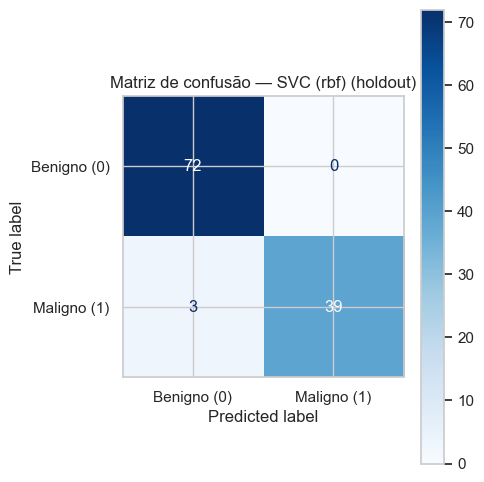

VN=72  FP=0  FN=3  VP=39


In [58]:
X_tr, X_ho, y_tr, y_ho = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)

champion_pipe_clf.fit(X_tr, y_tr)
y_pred_ho = champion_pipe_clf.predict(X_ho)

cm = confusion_matrix(y_ho, y_pred_ho)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"]).plot(ax=ax, cmap="Blues")
ax.set_title(f"Matriz de confusão — {champion_clf_name} (holdout)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"VN={tn}  FP={fp}  FN={fn}  VP={tp}")

**Interpretação:** no holdout estratificado (20% do treino), o modelo campeão acerta 72 benignos (VN) e 39 malignos (VP), não gera nenhum falso positivo (FP = 0) e erra 3 malignos classificados como benignos (FN = 3). Nesse contexto clínico, o **falso negativo é o erro mais caro**: significa dizer a uma paciente com câncer que o tumor é benigno, atrasando o diagnóstico e o tratamento — o custo humano é muito maior do que o de um falso positivo, que na pior das hipóteses gera exames adicionais para confirmar um resultado que era benigno.

---
# Parte 3 — Submissão no Kaggle

In [59]:
sample_sub_reg_path = "regressao/sample_submission.csv"
sample_sub_clf_path = "classiicacao/sample_submission.csv"

has_sample_reg = os.path.exists(sample_sub_reg_path)
has_sample_clf = os.path.exists(sample_sub_clf_path)
print("sample_submission.csv (regressão) encontrado?", has_sample_reg)
print("sample_submission.csv (classificação) encontrado?", has_sample_clf)
if not has_sample_reg or not has_sample_clf:
    print("AVISO: sample_submission.csv não está no diretório. Usando o cabeçalho do enunciado:")
    print("  regressão:      id,score      (id começando em 0)")
    print("  classificação:  id,diagnosis  (id começando em 0, diagnosis em 1/0)")

sample_submission.csv (regressão) encontrado? False
sample_submission.csv (classificação) encontrado? False
AVISO: sample_submission.csv não está no diretório. Usando o cabeçalho do enunciado:
  regressão:      id,score      (id começando em 0)
  classificação:  id,diagnosis  (id começando em 0, diagnosis em 1/0)


**1-2.** Modelo campeão de cada parte é retreinado em 100% do respectivo `train`. Como o pré-processamento está dentro do `Pipeline` (`ColumnTransformer`), `fit` roda só no treino completo e o `test` passa apenas por `transform`/`predict` — sem risco de vazamento e sem precisar de `reindex` manual de colunas (isso seria necessário só com `get_dummies` solto, que não é o caso aqui).

In [60]:
final_reg_pipe = grid_reg.best_estimator_

pred_score = final_reg_pipe.predict(test_reg)
pred_score_clipped = np.clip(pred_score, 0, 20)

submission_reg = pd.DataFrame({
    "id": range(0, len(test_reg)),
    "score": pred_score_clipped,
})
submission_reg.head()

,id,score
0,0,12.628676
1,1,10.531716
2,2,5.464703
3,3,11.276978
4,4,12.763518


In [61]:
final_clf_pipe = Pipeline([("preprocess", preprocess_clf), ("model", clf_models[champion_clf_name])])
final_clf_pipe.fit(X_clf, y_clf)

pred_diagnosis = final_clf_pipe.predict(test_clf)

submission_clf = pd.DataFrame({
    "id": range(0, len(test_clf)),
    "diagnosis": pred_diagnosis.astype(int),
})
submission_clf.head()

,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0


In [62]:
reg_out_path = "regressao/submission.csv"
clf_out_path = "classiicacao/submission.csv"

submission_reg.to_csv(reg_out_path, index=False)
submission_clf.to_csv(clf_out_path, index=False)

print("Salvo:", reg_out_path)
print("Salvo:", clf_out_path)

Salvo: regressao/submission.csv
Salvo: classiicacao/submission.csv


**5. Checagens obrigatórias**

In [63]:
print("=== Regressão ===")
print("linhas na submissão:", len(submission_reg), " | linhas em test.csv:", len(test_reg))
if len(submission_reg) != 20:
    print(f"AVISO: o enunciado fala em 20 linhas de teste, mas regressao/test.csv tem {len(test_reg)} linhas de fato; a submissão acompanha o test.csv real.")
print("NaN na submissão:", submission_reg.isna().sum().sum())
print("score fora de [0, 20]:", ((submission_reg['score'] < 0) | (submission_reg['score'] > 20)).sum())
assert len(submission_reg) == len(test_reg)
assert submission_reg.isna().sum().sum() == 0
assert submission_reg["score"].between(0, 20).all()

=== Regressão ===
linhas na submissão: 40  | linhas em test.csv: 40
AVISO: o enunciado fala em 20 linhas de teste, mas regressao/test.csv tem 40 linhas de fato; a submissão acompanha o test.csv real.
NaN na submissão: 0
score fora de [0, 20]: 0


In [64]:
print("=== Classificação ===")
print("linhas na submissão:", len(submission_clf), " | linhas em test2.csv:", len(test_clf))
if len(submission_clf) != 20:
    print(f"AVISO: o enunciado fala em 20 linhas de teste, mas classiicacao/test2.csv tem {len(test_clf)} linhas de fato; a submissão acompanha o test2.csv real.")
print("NaN na submissão:", submission_clf.isna().sum().sum())
valores_validos = set(submission_clf["diagnosis"].unique()) <= {0, 1}
print("apenas valores válidos (0/1)?", valores_validos)
assert len(submission_clf) == len(test_clf)
assert submission_clf.isna().sum().sum() == 0
assert valores_validos

=== Classificação ===
linhas na submissão: 40  | linhas em test2.csv: 40
AVISO: o enunciado fala em 20 linhas de teste, mas classiicacao/test2.csv tem 40 linhas de fato; a submissão acompanha o test2.csv real.
NaN na submissão: 0
apenas valores válidos (0/1)? True


## Resumo final

In [65]:
print("=" * 60)
print("RESUMO")
print("=" * 60)
print(f"Regressão      | modelo campeão: {champion_reg_name}")
print(f"               | RMSE (CV, com tuning): {-grid_reg.best_score_:.4f}")
print(f"               | hiperparâmetros: {grid_reg.best_params_}")
print(f"Classificação  | modelo campeão: {champion_clf_name}")
print(f"               | acurácia (CV): {clf_results_df.iloc[0]['acuracia_media']:.4f}  (baseline: {baseline_acc:.4f})")
print()
print("Arquivos gerados:")
print(" -", os.path.abspath(reg_out_path))
print(" -", os.path.abspath(clf_out_path))

RESUMO
Regressão      | modelo campeão: RandomForestRegressor
               | RMSE (CV, com tuning): 3.2046
               | hiperparâmetros: {'model__max_depth': 10, 'model__n_estimators': 300}
Classificação  | modelo campeão: SVC (rbf)
               | acurácia (CV): 0.9772  (baseline: 0.6274)

Arquivos gerados:
 - c:\Users\Smart\projetos\analytica\ufrj-analytica-training\entregaveis\machine_learning\regressao\submission.csv
 - c:\Users\Smart\projetos\analytica\ufrj-analytica-training\entregaveis\machine_learning\classiicacao\submission.csv
